# Sampling strategy walkthrough

## Environment preparation

Run the next cell to define helper classes and functions that are shared by all examples.

In [1]:
from __future__ import annotations

import math
from collections.abc import Iterable, Mapping
from dataclasses import dataclass
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

from pysatl_core.distributions import AnalyticalComputation, DefaultComputationStrategy
from pysatl_core.distributions.distribution import Distribution
from pysatl_core.distributions.support import ExplicitTableDiscreteSupport, Support
from pysatl_core.sampling import (
    DefaultUnuranSamplingStrategy,
    UnuranMethod,
    UnuranMethodConfig,
)
from pysatl_core.types import CharacteristicName, EuclideanDistributionType, Kind


@dataclass(slots=True)
class CustomDistribution(Distribution):
    """Minimal Distribution wrapper used solely for the UNU.RAN examples."""

    name: str
    kind: Kind
    parameters: dict[str, Any]
    _analytical: dict[str, AnalyticalComputation[Any, Any]]
    _sampling_strategy: DefaultUnuranSamplingStrategy
    _distribution_type: EuclideanDistributionType
    _computation_strategy: DefaultComputationStrategy
    _support: Support | None

    def __init__(
        self,
        name: str,
        kind: Kind,
        analytical_computations: Iterable[AnalyticalComputation[Any, Any]]
        | Mapping[str, AnalyticalComputation[Any, Any]],
        sampling_strategy: DefaultUnuranSamplingStrategy,
        support: Support | None = None,
        *,
        parameters: Mapping[str, Any] | None = None,
    ) -> None:
        self.name = name
        self.kind = kind
        self.parameters = dict(parameters or {})
        self._distribution_type = EuclideanDistributionType(kind=kind, dimension=1)
        if isinstance(analytical_computations, Mapping):
            self._analytical = dict(analytical_computations)
        else:
            self._analytical = {ac.target: ac for ac in analytical_computations}
        self._sampling_strategy = sampling_strategy
        self._computation_strategy = DefaultComputationStrategy()
        self._support = support

    @property
    def distribution_type(self) -> EuclideanDistributionType:
        return self._distribution_type

    @property
    def analytical_computations(self) -> Mapping[str, AnalyticalComputation[Any, Any]]:
        return self._analytical

    @property
    def sampling_strategy(self) -> DefaultUnuranSamplingStrategy:
        return self._sampling_strategy

    def set_sampling_strategy(self, sampling_strategy: DefaultUnuranSamplingStrategy) -> None:
        self._sampling_strategy = sampling_strategy

    @property
    def computation_strategy(self) -> DefaultComputationStrategy:
        return self._computation_strategy

    @property
    def support(self) -> Support | None:  # type: ignore[override]
        return self._support


def _save_and_show(fig: plt.Figure, filename: str) -> None:
    display(fig)
    plt.close(fig)


def _plot_histogram(
    title: str, xs: np.ndarray, reference: np.ndarray, samples: np.ndarray, filename: str
) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(title)
    ax.plot(xs, reference, label="Reference", color="tab:red")
    ax.hist(samples, bins=80, density=True, alpha=0.55, label="Sampled", color="tab:blue")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)
    _save_and_show(fig, filename)


def _plot_cdf(
    title: str, xs: np.ndarray, cdf: np.ndarray, samples: np.ndarray, filename: str
) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(title)
    ax.plot(xs, cdf, label="Analytical CDF", color="tab:red")
    sorted_samples = np.sort(samples)
    ecdf = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)
    ax.plot(sorted_samples, ecdf, label="Empirical CDF", linestyle="--", color="tab:blue")
    ax.set_xlabel("x")

    ax.set_ylabel("Probability")
    ax.legend()
    ax.grid(True, alpha=0.3)
    _save_and_show(fig, filename)


def _plot_discrete_pmf(
    title: str, pmf: Mapping[int, float], samples: np.ndarray, filename: str
) -> None:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title(title)
    xs = np.array(sorted(pmf.keys()))
    ax.bar(xs - 0.15, [pmf[int(x)] for x in xs], width=0.3, label="Ideal", color="tab:red")
    unique, counts = np.unique(samples.astype(int), return_counts=True)
    freqs = counts / counts.sum()
    ax.bar(unique + 0.15, freqs, width=0.3, label="Sampled", color="tab:blue", alpha=0.7)
    ax.set_xlabel("value")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    _save_and_show(fig, filename)

## Experiment 1 — Exponential distribution
AUTO mode with an analytical PDF. Demonstrates the basic setup and validates mean/std.

=== Example 1: Exponential PDF sampled with AUTO ===
Mean ≈ 0.4996 (expected 0.5000)
Std  ≈ 0.4984 (expected 0.5000)


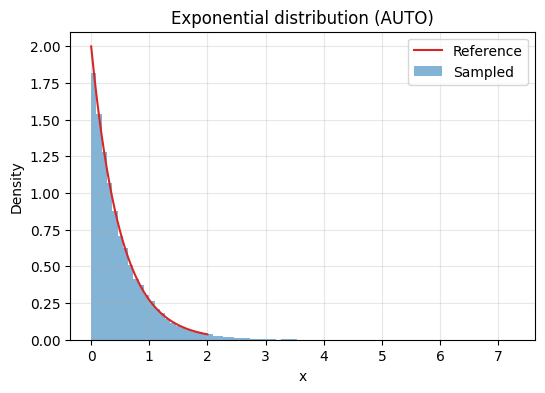

In [2]:
def example_exponential_auto() -> None:
    print("=== Example 1: Exponential PDF sampled with AUTO ===")
    lam = 2.0

    def pdf_func(x: float, **_: Any) -> float:
        return lam * math.exp(-lam * x) if x >= 0 else 0.0

    distr = CustomDistribution(
        name="Exp(λ=2)",
        kind=Kind.CONTINUOUS,
        analytical_computations=[
            AnalyticalComputation(target=CharacteristicName.PDF, func=pdf_func),
        ],
        sampling_strategy=DefaultUnuranSamplingStrategy(),
    )

    data = distr.sample(30_000).flatten()
    print(f"Mean ≈ {data.mean():.4f} (expected {1/lam:.4f})")
    print(f"Std  ≈ {data.std():.4f} (expected {1/lam:.4f})")

    xs = np.linspace(0, 4 / lam, 400)
    pdf_vals = np.array([pdf_func(x) for x in xs])
    _plot_histogram("Exponential distribution (AUTO)", xs, pdf_vals, data, "exp_auto_pdf.png")


example_exponential_auto()

## Experiment 2 — Weibull with the NINV method
We rely on an analytical CDF for a heavy tail. Validate empirical moments and compare the analytical CDF with the ECDF.


=== Example 2: Weibull CDF sampled with NINV ===
Mean ≈ 0.7511 (expected 0.7525)
Std  ≈ 0.6333 (expected 0.6298)


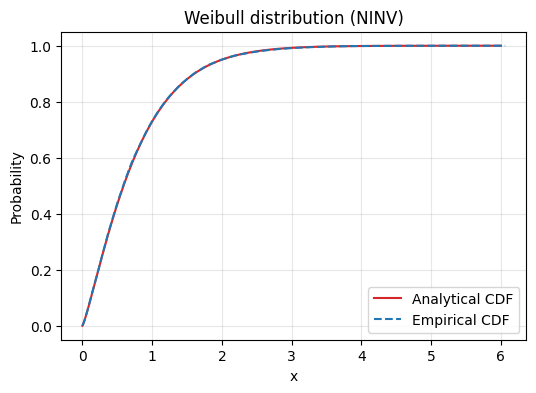

In [3]:
def example_cdf_ninv() -> None:
    print("\n=== Example 2: Weibull CDF sampled with NINV ===")
    k = 1.2
    lam = 0.8

    def cdf_func(x: float, **_: Any) -> float:
        if x <= 0:
            return 0.0
        return 1 - math.exp(-((x / lam) ** k))

    expected_mean = lam * math.gamma(1 + 1 / k)
    expected_std = lam * math.sqrt(math.gamma(1 + 2 / k) - math.gamma(1 + 1 / k) ** 2)

    distr = CustomDistribution(
        name="Weibull(λ=0.8, k=1.2)",
        kind=Kind.CONTINUOUS,
        analytical_computations=[
            AnalyticalComputation(target=CharacteristicName.CDF, func=cdf_func),
        ],
        sampling_strategy=DefaultUnuranSamplingStrategy(
            config=UnuranMethodConfig(
                method=UnuranMethod.NINV,
                use_cdf=True,
                use_pdf=False,
            )
        ),
    )

    data = distr.sample(35_000).flatten()
    print(f"Mean ≈ {data.mean():.4f} (expected {expected_mean:.4f})")
    print(f"Std  ≈ {data.std():.4f} (expected {expected_std:.4f})")
    xs = np.linspace(0, 6, 400)
    cdf_vals = np.array([cdf_func(x) for x in xs])
    _plot_cdf("Weibull distribution (NINV)", xs, cdf_vals, data, "weibull_cdf_ninv.png")


example_cdf_ninv()

## Experiment 3 — discrete DGT
Shows how a bounded support and a hand-written PMF allow using DGT without relying on registry characteristics.


=== Example 3: Discrete PMF sampled with DGT ===
Observed frequencies:
  value 0 → 0.150 (expected 0.150)
  value 1 → 0.502 (expected 0.500)
  value 2 → 0.252 (expected 0.250)
  value 3 → 0.096 (expected 0.100)


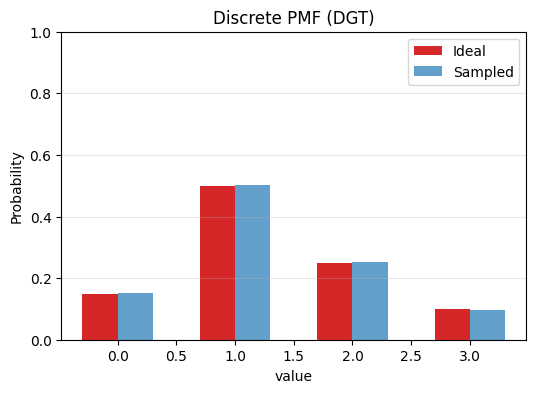

In [4]:
def example_discrete_dgt() -> None:
    print("\n=== Example 3: Discrete PMF sampled with DGT ===")
    pmf = {0: 0.15, 1: 0.5, 2: 0.25, 3: 0.10}
    support = ExplicitTableDiscreteSupport(list(pmf.keys()))

    distr = CustomDistribution(
        name="Custom discrete",
        kind=Kind.DISCRETE,
        analytical_computations={
            CharacteristicName.PMF: AnalyticalComputation(
                target=CharacteristicName.PMF,
                func=lambda x, **_: pmf.get(int(x), 0.0),
            )
        },
        sampling_strategy=DefaultUnuranSamplingStrategy(
            config=UnuranMethodConfig(
                method=UnuranMethod.DGT,
                use_registry_characteristics=False,
            )
        ),
        support=support,
    )

    data = distr.sample(25_000).flatten()
    unique, counts = np.unique(data, return_counts=True)
    print("Observed frequencies:")
    for value, freq in zip(unique, counts / counts.sum(), strict=False):
        print(f"  value {int(value)} → {freq:.3f} (expected {pmf[int(value)]:.3f})")

    _plot_discrete_pmf("Discrete PMF (DGT)", pmf, data, "discrete_dgt.png")


example_discrete_dgt()

## Experiment 4 — normal distribution (AUTO vs PINV)
Compare the two methods on the same PDF: AUTO selects an optimal strategy automatically, while PINV is enforced manually. We illustrate the differences via histograms.


=== Example 4: Normal PDF sampled with AUTO vs PINV ===
Expected mean ≈ 0.000, std ≈ 1.000
AUTO: mean=-0.004, std=1.006
PINV: mean=0.009, std=1.004


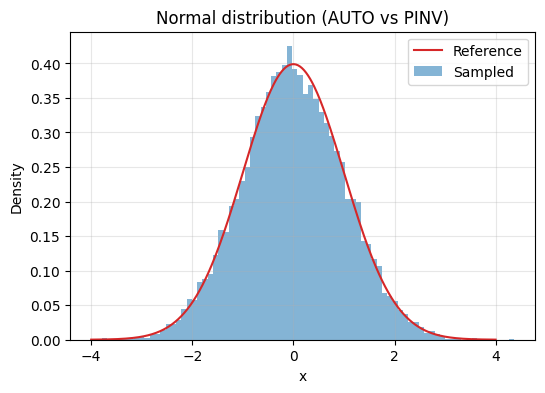

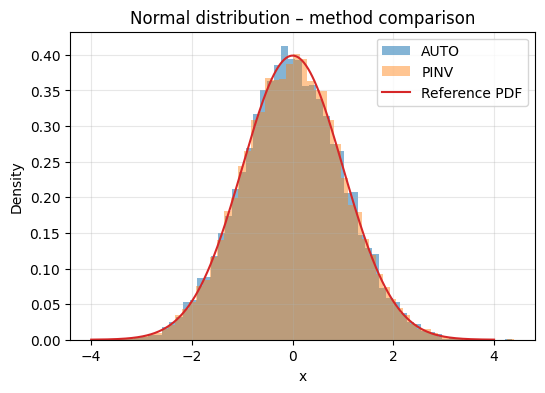

In [5]:
def example_normal_overrides() -> None:
    print("\n=== Example 4: Normal PDF sampled with AUTO vs PINV ===")

    def pdf_func(x: float, **_: Any) -> float:
        return (1 / math.sqrt(2 * math.pi)) * math.exp(-0.5 * x * x)

    distr = CustomDistribution(
        name="Normal N(0,1)",
        kind=Kind.CONTINUOUS,
        analytical_computations=[
            AnalyticalComputation(target=CharacteristicName.PDF, func=pdf_func),
        ],
        sampling_strategy=DefaultUnuranSamplingStrategy(),
    )

    strategy = DefaultUnuranSamplingStrategy(config=UnuranMethodConfig(method=UnuranMethod.PINV))

    distr_pinv = CustomDistribution(
        name="Normal N(0,1)",
        kind=Kind.CONTINUOUS,
        analytical_computations=[
            AnalyticalComputation(target=CharacteristicName.PDF, func=pdf_func),
        ],
        sampling_strategy=strategy,
    )

    data_auto = distr.sample(15_000).flatten()
    data_pinv = distr_pinv.sample(15_000).flatten()
    print("Expected mean ≈ 0.000, std ≈ 1.000")
    print(f"AUTO: mean={data_auto.mean():.3f}, std={data_auto.std():.3f}")
    print(f"PINV: mean={data_pinv.mean():.3f}, std={data_pinv.std():.3f}")

    xs = np.linspace(-4, 4, 400)
    pdf_vals = np.array([pdf_func(x) for x in xs])
    _plot_histogram(
        "Normal distribution (AUTO vs PINV)", xs, pdf_vals, data_auto, "normal_auto_hist.png"
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.set_title("Normal distribution – method comparison")
    ax.hist(data_auto, bins=60, density=True, alpha=0.55, label="AUTO", color="tab:blue")
    ax.hist(data_pinv, bins=60, density=True, alpha=0.45, label="PINV", color="tab:orange")
    ax.plot(xs, pdf_vals, label="Reference PDF", color="tab:red")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)
    _save_and_show(fig, "normal_auto_vs_pinv.png")


example_normal_overrides()